# CNN Applied to videos - part 1

To analyze movement, we must learn to analyze videos, as videos can capture movement. 

Videos are nothing more than a sequence of images, captured one shortly after the other. 

<div style="text-align:center">
<img src="images/imagesequence.png" alt="plot" width="800" />
</div>

Thus, analyzing videos is as simple as analyzing the sequence of videos that conform the video. 

All images in the video are of the same size, and the time between consecutive frames is called the frame rate and measures in frames per second (FPS). Common values are 30 FPS (30 frames every second, time between frames is 33ms) or 60 FPS (60 frames every second, time between frames is 16ms)

We use this technique in the previous notebook to analyze the movement of the subject during the TUG test. This process involves converting the video into a sequence of frames, storing the frames, and accessing each frame at the time for processing.

As you can see, this is a slow process that requires seeing each frame at least twice, once for storing and another for processing.

There is a better solution, which involves using specialized libraries to work with videos. These libraries do not read all the frames of the video at once, rather, they store the location of the video and quickly access each frame once requested. There are many libraries to work with videos, one of the most commonly used is `OpenCV` (Open Computer Vision).

OpenCV is a large library with many computer vision applications; in this case, we will only use it for accessing video frames. You should already have OpenCV installed in your environment. If you need to install/update, you can use

```
!pip install opencv-python --upgrade
```



### Learning Objective

The objective of this notebook is to learn how to load and process videos in Python, and apply CNNs to videos. 

In [1]:
import cv2 # This is the OpenCV library, used for image processing and computer vision tasks
import matplotlib.pyplot as plt # This is the Matplotlib library, used for plotting and visualizing data
from ultralytics import YOLO # This is the Ultralytics library, used for object
import numpy as np
import pandas as pd

In [32]:
#we will work with the TUG video, but this time we will use the video, not the individual frames,

# we can now load the video using OpenCV
video = cv2.VideoCapture("data/TUG.mp4")

`video` is now an object that contains information about the video

In [17]:
print("Video loaded successfully:", video.isOpened())
print("Total number of frames in the video:", int(video.get(cv2.CAP_PROP_FRAME_COUNT)))
print("Frames per second (FPS) of the video:", video.get(cv2.CAP_PROP_FPS))
print("Width of the video frames:", int(video.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("Height of the video frames:", int(video.get(cv2.CAP_PROP_FRAME_HEIGHT)))
print(f"Duration of the video (seconds): {video.get(cv2.CAP_PROP_FRAME_COUNT) / video.get(cv2.CAP_PROP_FPS)} s")


Video loaded successfully: True
Total number of frames in the video: 457
Frames per second (FPS) of the video: 25.0
Width of the video frames: 640
Height of the video frames: 360
Duration of the video (seconds): 18.28 s


Note: Sometimes this information is not accurate, it depends on how the video was created. Some programs do not properly store the video metadata and fill this information with false data. 

You can also access the individual frames

In [18]:
valid, frame = video.read() # read the first frame of the video, this will be used to get the dimensions of the frames and to run the model on it
print("Frame read successfully:", valid)
print("Frame dimensions:", frame.shape)
print("Frame time stamp (seconds):", video.get(cv2.CAP_PROP_POS_MSEC) / 1000)

Frame read successfully: True
Frame dimensions: (360, 640, 3)
Frame time stamp (seconds): 0.0


You can visualize the frame 

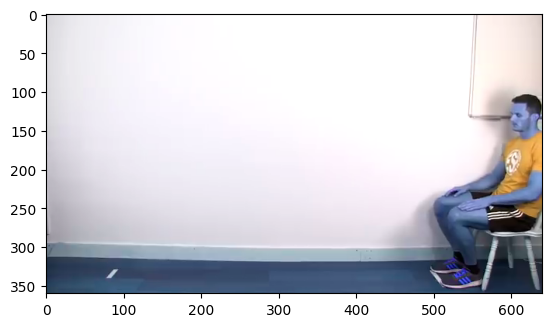

In [20]:
plt.imshow(frame)

Note that the colors are all weird. This is because OpenCV reads the color channels in an order different from what Matplolib expects. 

In OpenCV, the color channels are read as B(blue)R(red)G(green), while Matplotlib expects R(Red)G(Green)B(Blue). This issue can be easily fixed with

Old color TVs used to work with images in BRG, and OpenCV inherited this standard.


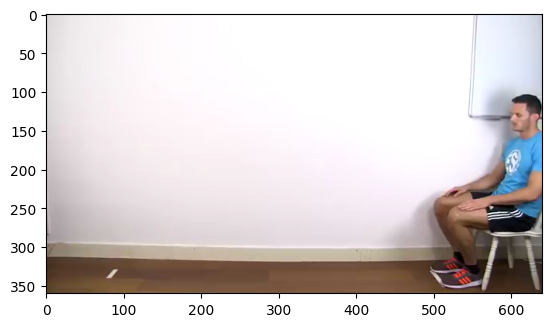

In [21]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)) # OpenCV uses BGR color format by default, we need to convert it to RGB for displaying with Matplotlib

To read the following frame, we simply need to call `read()` again

In [22]:
valid, frame = video.read() # read the first frame of the video, this will be used to get the dimensions of the frames and to run the model on it
print("Frame read successfully:", valid)
print("Frame dimensions:", frame.shape)
print("Frame time stamp (seconds):", video.get(cv2.CAP_PROP_POS_MSEC) / 1000)

Frame read successfully: True
Frame dimensions: (360, 640, 3)
Frame time stamp (seconds): 0.04


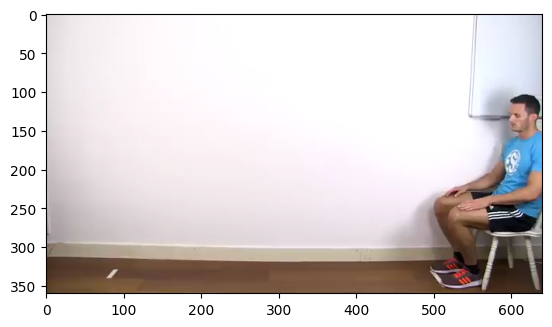

In [23]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)) # OpenCV uses BGR color format by default, we need to convert it to RGB for displaying with Matplotlib

Note that every time you call `read()`, you will retrieve the next frame in the sequence. To go back to the start of the sequence, you need to `release` the video using 

```
video.release()
```

Alternatively, you can go to any specific point in time or frame number using the `set` property

Frame read successfully: True
Frame dimensions: (360, 640, 3)
Frame time stamp (seconds): 4.0


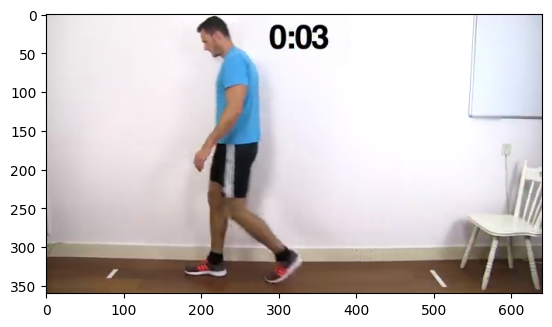

In [25]:
video.set(cv2.CAP_PROP_POS_FRAMES, 100) # set the video to the 100th frame
valid, frame = video.read() # read the 100th frame of the video
print("Frame read successfully:", valid)
print("Frame dimensions:", frame.shape)
print("Frame time stamp (seconds):", video.get(cv2.CAP_PROP_POS_MSEC) / 1000)
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)) 
video.release() # release the video when done to free up resources

To read all the consecutive frames in a video, we can use a `while` loop that checks if a frame was successfully acquired 

In [26]:
video = cv2.VideoCapture("data/TUG.mp4")
while True:
    valid, frame = video.read()
    if not valid:
        break
    print("Frame time stamp (seconds):", video.get(cv2.CAP_PROP_POS_MSEC) / 1000)
video.release() # release the video when done to free up resources

Frame time stamp (seconds): 0.0
Frame time stamp (seconds): 0.04
Frame time stamp (seconds): 0.08
Frame time stamp (seconds): 0.12
Frame time stamp (seconds): 0.16
Frame time stamp (seconds): 0.2
Frame time stamp (seconds): 0.24
Frame time stamp (seconds): 0.28
Frame time stamp (seconds): 0.32
Frame time stamp (seconds): 0.36
Frame time stamp (seconds): 0.4
Frame time stamp (seconds): 0.44
Frame time stamp (seconds): 0.48
Frame time stamp (seconds): 0.52
Frame time stamp (seconds): 0.56
Frame time stamp (seconds): 0.6
Frame time stamp (seconds): 0.64
Frame time stamp (seconds): 0.68
Frame time stamp (seconds): 0.72
Frame time stamp (seconds): 0.76
Frame time stamp (seconds): 0.8
Frame time stamp (seconds): 0.84
Frame time stamp (seconds): 0.88
Frame time stamp (seconds): 0.92
Frame time stamp (seconds): 0.96
Frame time stamp (seconds): 1.0
Frame time stamp (seconds): 1.04
Frame time stamp (seconds): 1.08
Frame time stamp (seconds): 1.12
Frame time stamp (seconds): 1.16
Frame time stamp

To read specific frames, you can use the `set` property. Say you want to read from frame 150

In [31]:
video = cv2.VideoCapture("data/TUG.mp4")
video.set(cv2.CAP_PROP_POS_FRAMES, 150) # set the video to the 150th frame
while True:
    valid, frame = video.read()
    if not valid:
        break
    print("Frame time stamp (seconds):", video.get(cv2.CAP_PROP_POS_MSEC) / 1000)
    print("Frame index:", video.get(cv2.CAP_PROP_POS_FRAMES))
video.release() # release the video when done to free up resources

Frame time stamp (seconds): 6.0
Frame index: 151.0
Frame time stamp (seconds): 6.04
Frame index: 152.0
Frame time stamp (seconds): 6.08
Frame index: 153.0
Frame time stamp (seconds): 6.12
Frame index: 154.0
Frame time stamp (seconds): 6.16
Frame index: 155.0
Frame time stamp (seconds): 6.2
Frame index: 156.0
Frame time stamp (seconds): 6.24
Frame index: 157.0
Frame time stamp (seconds): 6.28
Frame index: 158.0
Frame time stamp (seconds): 6.32
Frame index: 159.0
Frame time stamp (seconds): 6.36
Frame index: 160.0
Frame time stamp (seconds): 6.4
Frame index: 161.0
Frame time stamp (seconds): 6.44
Frame index: 162.0
Frame time stamp (seconds): 6.48
Frame index: 163.0
Frame time stamp (seconds): 6.520000000000001
Frame index: 164.0
Frame time stamp (seconds): 6.5600000000000005
Frame index: 165.0
Frame time stamp (seconds): 6.6000000000000005
Frame index: 166.0
Frame time stamp (seconds): 6.640000000000001
Frame index: 167.0
Frame time stamp (seconds): 6.68
Frame index: 168.0
Frame time st

## Activity

Access the video from frame 50 until frame 150. 


We can replicate the same results from our previous notebook reading the frames directly from the video

In [ ]:

model = YOLO("models/yolo26s.pt")

video= cv2.VideoCapture("data/TUG.mp4")

target_names = {"person", "chair"}
name_to_id = {name: idx for idx, name in model.names.items()}
target_ids = [name_to_id[name] for name in target_names if name in name_to_id]

positions = []


while True:
    valid, frame = video.read()
    if not valid:
        break
    
    r = model(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), classes=target_ids, verbose=False)[0]

    frame_data = {
        "frame": video.get(cv2.CAP_PROP_POS_FRAMES),
        "time": video.get(cv2.CAP_PROP_POS_MSEC) / 1000,
        "person_x": np.nan, "person_y": np.nan, 
        "chair_x": np.nan,  "chair_y": np.nan, 
    }

    if r.boxes is not None and len(r.boxes) > 0:
        cls = r.boxes.cls.cpu().numpy().astype(int)
        conf = r.boxes.conf.cpu().numpy()
        xyxy = r.boxes.xyxy.cpu().numpy()  # x1, y1, x2, y2

        for label in ["person", "chair"]:
            cid = name_to_id[label]
            idx = np.where(cls == cid)[0]
            if idx.size > 0:
                best = idx[np.argmax(conf[idx])]  # highest confidence detection
                x1, y1, x2, y2 = xyxy[best]
                # Calculate center and dimensions
                x = (x1 + x2) / 2
                y = (y1 + y2) / 2
                frame_data[f"{label}_x"] = float(x)
                frame_data[f"{label}_y"] = float(y)
    positions.append(frame_data)
video.release() # release the video when done to free up resources

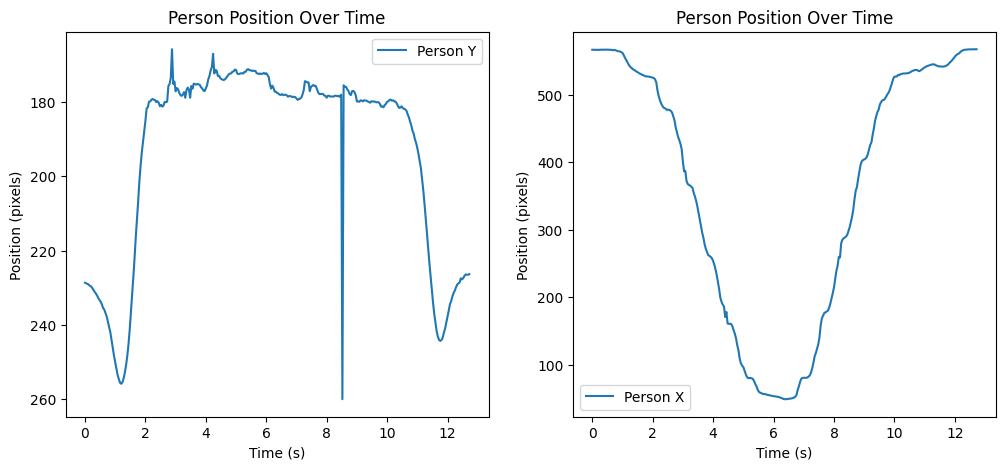

In [ ]:

df = pd.DataFrame(positions)
fig, ax = plt.subplots(1,2,figsize=(12, 5))
ax[0].plot(df["time"], df["person_y"], label="Person Y")
ax[1].plot(df["time"], df["person_x"], label="Person X")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Position (pixels)")
ax[0].set_title("Person Position Over Time")
ax[0].legend()
ax[0].invert_yaxis() # Invert y-axis to match image coordinates (top-left is (0,0))

ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Position (pixels)")
ax[1].set_title("Person Position Over Time")
ax[1].legend()


Many models also include the ability to *track* the objects in the video. Tracking can improve object localization assuming that the position does not change too much between frames 

In [ ]:

model = YOLO("models/yolo26s.pt")

video= cv2.VideoCapture("data/TUG.mp4")

target_names = {"person", "chair"}
name_to_id = {name: idx for idx, name in model.names.items()}
target_ids = [name_to_id[name] for name in target_names if name in name_to_id]

positions = []


while True:
    valid, frame = video.read()
    if not valid:
        break
    
    r = model.track(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), classes=target_ids, persist=True, verbose=False)[0]

    frame_data = {
        "frame": video.get(cv2.CAP_PROP_POS_FRAMES),
        "time": video.get(cv2.CAP_PROP_POS_MSEC) / 1000,
        "person_x": np.nan, "person_y": np.nan, 
        "chair_x": np.nan,  "chair_y": np.nan,  
    }

    if r.boxes is not None and len(r.boxes) > 0:
        cls = r.boxes.cls.cpu().numpy().astype(int)
        conf = r.boxes.conf.cpu().numpy()
        xyxy = r.boxes.xyxy.cpu().numpy()  # x1, y1, x2, y2

        for label in ["person", "chair"]:
            cid = name_to_id[label]
            idx = np.where(cls == cid)[0]
            if idx.size > 0:
                best = idx[np.argmax(conf[idx])]  # highest confidence detection
                x1, y1, x2, y2 = xyxy[best]
                # Calculate center and dimensions
                x = (x1 + x2) / 2
                y = (y1 + y2) / 2
                frame_data[f"{label}_x"] = float(x)
                frame_data[f"{label}_y"] = float(y)
    positions.append(frame_data)
video.release() # release the video when done to free up resources

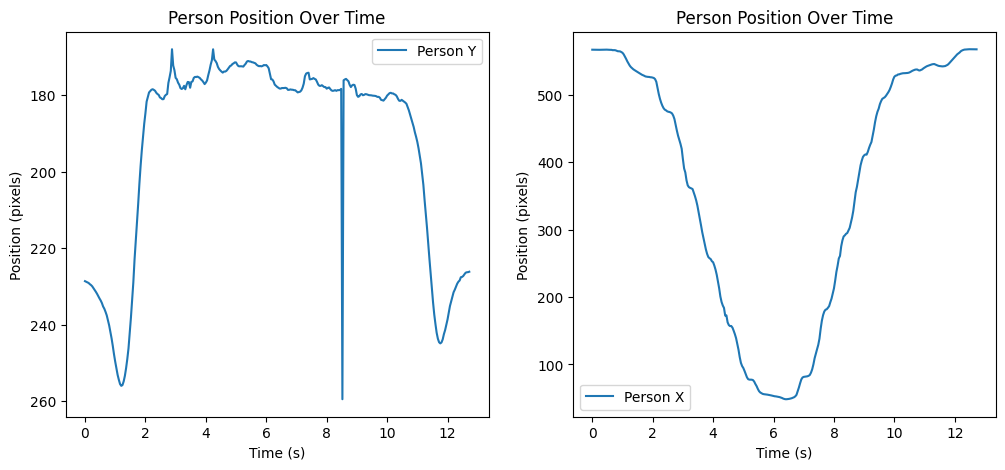

In [11]:
df = pd.DataFrame(positions)
fig, ax = plt.subplots(1,2,figsize=(12, 5))
ax[0].plot(df["time"], df["person_y"], label="Person Y")
ax[1].plot(df["time"], df["person_x"], label="Person X")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Position (pixels)")
ax[0].set_title("Person Position Over Time")
ax[0].legend()
ax[0].invert_yaxis() # Invert y-axis to match image coordinates (top-left is (0,0))

ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Position (pixels)")
ax[1].set_title("Person Position Over Time")
ax[1].legend()